<a href="https://colab.research.google.com/github/TheGamerJNC/Proyecto2_IntroduccionALaInteligenciaArtificial/blob/main/Proyecto2_Introducci%C3%B3nALaInteligenciaArtificial_JuanNavarroCastagnoli.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1 - Importar Librerías

## ⋅ Librerías Base

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## ⋅ Librerías para Deep Learning

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

## ⋅ Librerías para Modelo Predefinido (ResNet50)

In [ ]:
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

In [ ]:
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Dispositivo CUDA actual: {torch.cuda.current_device()}")
    print(f"Nombre del dispositivo CUDA: {torch.cuda.get_device_name(0)}")

CUDA disponible: True
Dispositivo CUDA actual: 0
Nombre del dispositivo CUDA: NVIDIA A100-SXM4-40GB


Si el resultado indica que `CUDA disponible: True` y muestra el nombre de tu GPU, significa que PyTorch está configurado para usarla.

Para ver la utilización en tiempo real durante el entrenamiento:

1.  **Ejecuta la celda `0sInuboLOi3-`** que contiene `!nvidia-smi`.
2.  **Luego, ejecuta la celda de entrenamiento `3FOlIY0pJQTh`**.
3.  **Vuelve a ejecutar la celda `0sInuboLOi3-` repetidamente** (o crea una nueva celda con `!watch -n 1 nvidia-smi` si estás en un entorno de terminal que lo soporta) *mientras la celda de entrenamiento está en ejecución*.

Observa la columna "`Util`" y "`Mem`" en la salida de `!nvidia-smi`. Si la GPU está siendo utilizada activamente, verás porcentajes significativos (por ejemplo, >0% en Util y un aumento en Mem) que indican que tu modelo está procesando datos en la GPU. Si estos valores permanecen en 0% o muy bajos, podría indicar que la GPU no está siendo utilizada o que el cuello de botella está en otro lugar (como la carga de datos en la CPU).

## ⋅ Librerías para Predicción

In [ ]:
from PIL import Image
import requests
from io import BytesIO

## ⋅ Otras Librerías

In [ ]:
import os

# 2 - Inicio de Sesión (KaggleHub) y Descarga de Datasets

In [ ]:
import kagglehub

kagglehub.login()

In [ ]:
# Download latest version
path = kagglehub.dataset_download("alessandrasala79/ai-vs-human-generated-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ai-vs-human-generated-dataset' dataset.
Path to dataset files: /kaggle/input/ai-vs-human-generated-dataset


In [ ]:
DATASET_DIR = path
print(f"DATASET_DIR configurado a: {DATASET_DIR}")

DATASET_DIR configurado a: /kaggle/input/ai-vs-human-generated-dataset


# 3 - Preparación de Datos

In [ ]:
import os
import pandas as pd # Necesario para leer el CSV
from PIL import Image # Necesario para cargar imágenes en el custom dataset

class CustomImageDataset(torch.utils.data.Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, pandas_read_csv_kwargs=None):
        if pandas_read_csv_kwargs is None:
            pandas_read_csv_kwargs = {}
        self.img_labels = pd.read_csv(annotations_file, **pandas_read_csv_kwargs)
        print(f"DEBUG: Columns of {os.path.basename(annotations_file)}: {self.img_labels.columns.tolist()}")
        self.img_dir = img_dir
        self.transform = transform
        self.classes = ['0', '1'] # Ajusta esto si tus etiquetas son 'ai'/'human' directamente

        # Determinar si la columna 'label' existe en el DataFrame
        self.has_labels = 'label' in self.img_labels.columns
        # Determinar qué columna contiene los nombres de archivo de las imágenes
        if 'file_name' in self.img_labels.columns:
            self.filename_col = 'file_name'
        elif 'id' in self.img_labels.columns:
            self.filename_col = 'id'
        else:
            raise ValueError(f"El archivo CSV {os.path.basename(annotations_file)} debe contener la columna 'file_name' o 'id'.")

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        # Acceder al nombre de archivo de la imagen usando la columna determinada
        img_relative_path = self.img_labels.iloc[idx][self.filename_col]

        if self.has_labels:
            label = self.img_labels.iloc[idx]['label']
        else:
            # Si no hay etiquetas, se devuelve un valor dummy. El consumidor del DataLoader
            # (ej. el bucle de validación) debe saber cómo manejar esto.
            label = -1
            # print(f"WARNING: No se encontró la columna 'label' en el dataset, devolviendo etiqueta dummy para el ítem {idx}")

        img_path = os.path.join(self.img_dir, img_relative_path)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)
        return image, label


data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Rutas a los directorios de imágenes y archivos CSV
train_csv_path = os.path.join(DATASET_DIR, 'train.csv')
val_csv_path = os.path.join(DATASET_DIR, 'test.csv') # Asumiendo que test.csv es para validación

# --- DEBUG: Imprimir los encabezados de los CSVs antes de cargarlos ---
print(f"Contenido de {train_csv_path}:")
!head {train_csv_path}
print(f"\nContenido de {val_csv_path}:")
!head {val_csv_path}
print("\n--- Cargando Datasets con configuraciones específicas ---")

# Cargar train_dataset con index_col=0 porque el train.csv tiene una columna de índice sin nombre.
train_dataset = CustomImageDataset(
    annotations_file=train_csv_path,
    img_dir=DATASET_DIR,
    transform=data_transforms,
    pandas_read_csv_kwargs={'index_col': 0} # Usa la primera columna como índice
)

# Cargar val_dataset sin index_col=0, ya que es probable que test.csv no tenga una columna de índice sin nombre.
val_dataset = CustomImageDataset(
    annotations_file=val_csv_path,
    img_dir=DATASET_DIR,
    transform=data_transforms,
    pandas_read_csv_kwargs={} # No usa la primera columna como índice, 'file_name' y 'label' serán columnas de datos.
)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0) # CAMBIADO a num_workers=0
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)   # CAMBIADO a num_workers=0

print(f"\nClases detectadas en el dataset de entrenamiento: {train_dataset.classes}")
print(f"Número de clases: {len(train_dataset.classes)}")
print(f"Tamaño del dataset de entrenamiento: {len(train_dataset)}")
print(f"Tamaño del dataset de validación: {len(val_dataset)}")

Contenido de /kaggle/input/ai-vs-human-generated-dataset/train.csv:
,file_name,label
0,train_data/a6dcb93f596a43249135678dfcfc17ea.jpg,1
1,train_data/041be3153810433ab146bc97d5af505c.jpg,0
2,train_data/615df26ce9494e5db2f70e57ce7a3a4f.jpg,1
3,train_data/8542fe161d9147be8e835e50c0de39cd.jpg,0
4,train_data/5d81fa12bc3b4cea8c94a6700a477cf2.jpg,1
5,train_data/25ea852f30594bc5915eb929682af429.jpg,0
6,train_data/e67085fb6d814cbabe08f978c738f3f7.jpg,1
7,train_data/041c36d9269146cdb88e7526e3b91651.jpg,0
8,train_data/4aea3b876247467c8d3713d4920148ab.jpg,1

Contenido de /kaggle/input/ai-vs-human-generated-dataset/test.csv:
id
test_data_v2/1a2d9fd3e21b4266aea1f66b30aed157.jpg
test_data_v2/ab5df8f441fe4fbf9dc9c6baae699dc7.jpg
test_data_v2/eb364dd2dfe34feda0e52466b7ce7956.jpg
test_data_v2/f76c2580e9644d85a741a42c6f6b39c0.jpg
test_data_v2/a16495c578b7494683805484ca27cf9f.jpg
test_data_v2/d08826f7ccab45c8935d8df5524b2869.jpg
test_data_v2/8ba52123cc7b4e3aa90e3947734197e0.jpg
test_data_v2/b107ac0040284

### 3.1 - Exploratory Data Analysis (EDA)
Visualizamos la distribución de clases y algunos ejemplos para entender los datos.

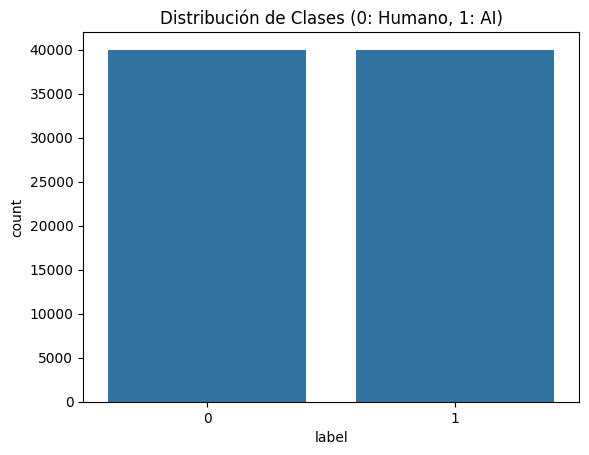

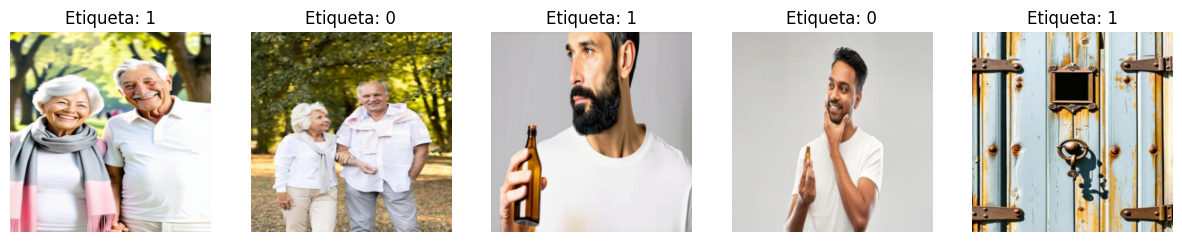

In [ ]:
import matplotlib.pyplot as plt

# 1. Distribución de clases
df_train = pd.read_csv(train_csv_path, index_col=0)
sns.countplot(x='label', data=df_train)
plt.title('Distribución de Clases (0: Humano, 1: AI)')
plt.show()

# 2. Visualizar muestras
def show_samples(dataset, num_samples=5):
    plt.figure(figsize=(15, 5))
    for i in range(num_samples):
        img, label = dataset[i]
        # Desnormalizar para visualizar
        img = img.permute(1, 2, 0).numpy()
        img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
        img = np.clip(img, 0, 1)
        plt.subplot(1, num_samples, i+1)
        plt.imshow(img)
        plt.title(f'Etiqueta: {label}')
        plt.axis('off')
    plt.show()

show_samples(train_dataset)

In [ ]:
print(f"Contenido de la carpeta principal del dataset ({DATASET_DIR}):")
!ls -F {DATASET_DIR}

# Si encuentras carpetas como 'ai' o 'human' directamente dentro de train_data, por favor, descomenta y ejecuta lo siguiente:
# print(f"\nContenido de {train_dir}/ai:")
# !ls -F {train_dir}/ai

# print(f"\nContenido de {train_dir}/human:")
# !ls -F {train_dir}/human

Contenido de la carpeta principal del dataset (/kaggle/input/ai-vs-human-generated-dataset):
test.csv  test_data_v2/  train.csv  train_data/


In [ ]:
train_csv_path = os.path.join(DATASET_DIR, 'train.csv')
print(f"Contenido de {train_csv_path}:")
!head {train_csv_path}

# También puedes cargar el CSV con pandas para una mejor visualización
# import pandas as pd
# df_train = pd.read_csv(train_csv_path)
# print(df_train.head())

Contenido de /kaggle/input/ai-vs-human-generated-dataset/train.csv:
,file_name,label
0,train_data/a6dcb93f596a43249135678dfcfc17ea.jpg,1
1,train_data/041be3153810433ab146bc97d5af505c.jpg,0
2,train_data/615df26ce9494e5db2f70e57ce7a3a4f.jpg,1
3,train_data/8542fe161d9147be8e835e50c0de39cd.jpg,0
4,train_data/5d81fa12bc3b4cea8c94a6700a477cf2.jpg,1
5,train_data/25ea852f30594bc5915eb929682af429.jpg,0
6,train_data/e67085fb6d814cbabe08f978c738f3f7.jpg,1
7,train_data/041c36d9269146cdb88e7526e3b91651.jpg,0
8,train_data/4aea3b876247467c8d3713d4920148ab.jpg,1


# 4 - Carga de Modelo y Fine-Tunning

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = resnet50(weights=ResNet50_Weights.DEFAULT)

for param in model.parameters():
  param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 218MB/s]


### 4.1 - Regularización (Dropout) y División de Datos
Mejoramos el modelo para evitar el sobreajuste y separamos un conjunto de test real.

In [ ]:
# Añadimos Dropout para regularización
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, 2)
)
model = model.to(device)

# Re-configuramos transformaciones con Data Augmentation para Feature Engineering
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# División entrenamiento/test (90/10) para tener métricas reales de testeo
train_size = int(0.9 * len(train_dataset))
test_size = len(train_dataset) - train_size
train_subset, test_subset = random_split(train_dataset, [train_size, test_size])

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=32, shuffle=False)

optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001, weight_decay=1e-4) # weight_decay es regularización L2

# 5 - Bucle de Entrenamiento y Validación

In [16]:
num_epochs = 5

# Listas para almacenar métricas y poder graficarlas
history_loss = []
history_acc = []

for epoch in range(num_epochs):
  # --- Fase de Entrenamiento ---
  model.train()
  running_loss = 0.0
  correct_train = 0
  total_train = 0

  for inputs, labels in train_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item() * inputs.size(0)
    _, predicted = outputs.max(1)
    total_train += labels.size(0)
    correct_train += predicted.eq(labels).sum().item()

  epoch_loss = running_loss / len(train_loader.dataset)
  epoch_acc = 100. * correct_train / total_train

  # Guardar en el historial
  history_loss.append(epoch_loss)
  history_acc.append(epoch_acc)

  # --- Fase de Validación ---
  model.eval()
  correct_val = 0
  total_val = 0
  val_loss = 0.0

  with torch.no_grad():
    for inputs, labels in test_loader:
      inputs, labels = inputs.to(device), labels.to(device)
      outputs = model(inputs)
      loss = criterion(outputs, labels)
      val_loss += loss.item() * inputs.size(0)
      _, predicted = outputs.max(1)
      total_val += labels.size(0)
      correct_val += predicted.eq(labels).sum().item()

  val_loss_avg = val_loss / len(test_loader.dataset)
  val_acc = 100. * correct_val / total_val
  print(f"Época [{epoch+1}/{num_epochs}] -> Pérdida: {epoch_loss:.4f} | Precisión Entren.: {epoch_acc:.2f}% | Pérdida Val: {val_loss_avg:.4f} | Precisión Val: {val_acc:.2f}%")

Época [1/5] -> Pérdida: 0.3282 | Precisión Entren.: 86.11% | Pérdida Val: 0.2196 | Precisión Val: 92.37%
Época [2/5] -> Pérdida: 0.3008 | Precisión Entren.: 87.36% | Pérdida Val: 0.2192 | Precisión Val: 92.15%
Época [3/5] -> Pérdida: 0.3040 | Precisión Entren.: 87.21% | Pérdida Val: 0.2205 | Precisión Val: 91.99%
Época [4/5] -> Pérdida: 0.3048 | Precisión Entren.: 87.29% | Pérdida Val: 0.2191 | Precisión Val: 92.08%
Época [5/5] -> Pérdida: 0.3007 | Precisión Entren.: 87.38% | Pérdida Val: 0.2166 | Precisión Val: 92.46%


# 6 - Visualización de Resultados y Métricas Finales

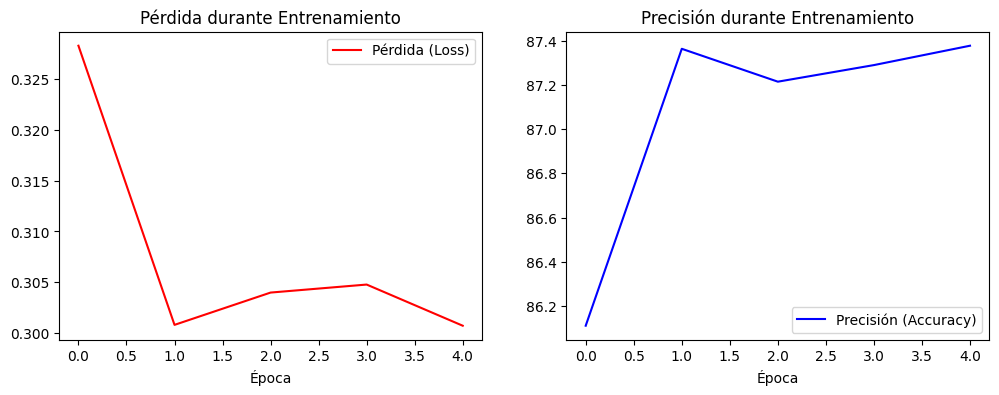


Reporte de Clasificación (Test Set Real):
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      4050
           1       0.92      0.92      0.92      3945

    accuracy                           0.92      7995
   macro avg       0.92      0.92      0.92      7995
weighted avg       0.92      0.92      0.92      7995



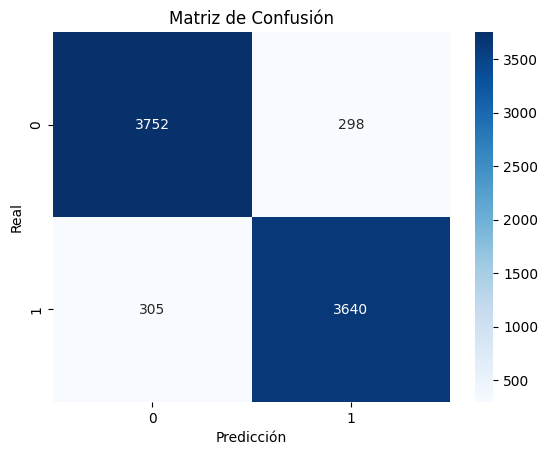

In [17]:
# Gráficas de entrenamiento
def plot_metrics(train_loss, train_acc):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_loss, label='Pérdida (Loss)', color='red')
    plt.title('Pérdida durante Entrenamiento')
    plt.xlabel('Época')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_acc, label='Precisión (Accuracy)', color='blue')
    plt.title('Precisión durante Entrenamiento')
    plt.xlabel('Época')
    plt.legend()
    plt.show()

# Llamada a la función con los datos recolectados
plot_metrics(history_loss, history_acc)

# Evaluación final en el conjunto de Test
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

from sklearn.metrics import classification_report, confusion_matrix
print("\nReporte de Clasificación (Test Set Real):")
print(classification_report(all_labels, all_preds))

sns.heatmap(confusion_matrix(all_labels, all_preds), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()